# The supervised head, trained in the open

Every encoder comparison in this project reduces to one recipe:

> freeze the encoder → mean-pool its output over time → train a **fully-connected layer** on top →
> score it on birds the layer never saw.

That is also the recipe AVES uses to benchmark itself, which is what makes our numbers and theirs
comparable at all. So it is worth running it with nothing hidden.

**What this notebook does**

1. Trains the fully-connected layer explicitly in PyTorch — visible loss curve, visible weights —
   and shows it agrees with the one-line scikit-learn version.
2. Sweeps all 12 encoder layers for two encoders.
3. Walks the **four ways this procedure silently produces a wrong number**. Each one produced a real
   wrong number in this project before it was caught.

**The task**: 11-way zebra finch call type. 3,412 curated clips, 48 birds, majority class 18.0%.

In [1]:
import json, sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "zfeval"))
sys.path.insert(0, str(ROOT / "zfeval/experiments"))
FEAT = Path.home() / "zf_labelset/zf_detection_dataset_v1/features"
ANA  = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"

import calltype11 as C11

rows    = [r for r in C11.collect() if r[3] in C11.KEEP11]
birds   = np.array([r[1].lower() for r in rows])
types   = np.array([r[3] for r in rows])
classes = sorted(set(types))
y       = np.array([classes.index(t) for t in types])

E_run11 = np.load(FEAT / "ct11_run11_emb.npy")   # (n_clips, 12 layers, 768)
E_aves  = np.load(FEAT / "ct11_aves_emb.npy")

print(f"{len(y):,} clips   {len(classes)} classes   {len(set(birds))} birds")
print(f"classes: {classes}")
print(f"majority class = {np.bincount(y).max()/len(y):.4f}  <- this is chance, not 1/11")
print(f"embeddings: {E_run11.shape}  (clips, layers, dims)")

3,412 clips   11 classes   48 birds
classes: [np.str_('Ag'), np.str_('Be'), np.str_('DC'), np.str_('Di'), np.str_('LT'), np.str_('Ne'), np.str_('So'), np.str_('Te'), np.str_('Th'), np.str_('Tu'), np.str_('Wh')]
majority class = 0.1797  <- this is chance, not 1/11
embeddings: (3412, 12, 768)  (clips, layers, dims)


## 1. What "mean-pooled embedding" actually means

The encoder emits one 768-dim vector every 20 ms. A 120 ms call is ~6 vectors; a 400 ms call is ~20.
To get one vector per clip we average over time.

That average is the entire input to the supervised layer. Everything about *when* things happened
inside the clip is gone — which is the right trade for single-call clips and the wrong one for
anything with internal sequence (song motifs, for instance).

In [2]:
# one clip, one layer -> one 768-vector. That is the whole feature.
i = 0
print(f"clip: {rows[i][0].name}")
print(f"call type: {types[i]}   bird: {birds[i]}")
print(f"layer-3 embedding shape: {E_run11[i, 3].shape}")
print(f"first 8 dims: {np.round(E_run11[i, 3][:8], 3)}")

clip: BlaBla0506_110302-AggC-04.wav
call type: Ag   bird: blabla0506
layer-3 embedding shape: (768,)
first 8 dims: [-0.605  0.873 -0.31  -0.449 -1.014 -0.015 -1.067 -0.202]


## 2. Training the fully-connected layer, explicitly

The "head" is a single `nn.Linear(768, 11)` — 768×11 weights plus 11 biases, **8,459 parameters**
against the encoder's 94.4 million. That ratio is the point of the whole design: the encoder is
frozen, so whatever the head achieves is a statement about the *features*, not about the head.

We train it with cross-entropy and watch the loss fall.

In [3]:
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

LAYER = 3
X = E_run11[:, LAYER]

# One fold, held out by BIRD -- see section 4 for why that matters so much.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
tr, te = next(iter(cv.split(X, y, birds)))
print(f"train {len(tr)} clips / {len(set(birds[tr]))} birds"
      f"   test {len(te)} clips / {len(set(birds[te]))} birds")
print(f"birds shared between train and test: {len(set(birds[tr]) & set(birds[te]))}")

# standardise using TRAINING statistics only
sc = StandardScaler().fit(X[tr])
Xtr = torch.tensor(sc.transform(X[tr]), dtype=torch.float32)
Xte = torch.tensor(sc.transform(X[te]), dtype=torch.float32)
ytr = torch.tensor(y[tr]); yte = torch.tensor(y[te])

torch.manual_seed(0)
head = nn.Linear(768, len(classes))
print(f"\nhead parameters: {sum(p.numel() for p in head.parameters()):,}")
print(f"encoder parameters (frozen): 94,370,944")

opt = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
lossf = nn.CrossEntropyLoss()
hist = []
for epoch in range(400):
    opt.zero_grad()
    loss = lossf(head(Xtr), ytr)
    loss.backward(); opt.step()
    if epoch % 20 == 0 or epoch == 399:
        with torch.no_grad():
            tr_acc = (head(Xtr).argmax(1) == ytr).float().mean().item()
            te_acc = (head(Xte).argmax(1) == yte).float().mean().item()
        hist.append((epoch, loss.item(), tr_acc, te_acc))

print(f"\n{'epoch':>6s} {'loss':>8s} {'train':>8s} {'test':>8s}")
for e, l, a, b in hist:
    print(f"{e:6d} {l:8.4f} {a:8.4f} {b:8.4f}")

train 2631 clips / 37 birds   test 781 clips / 11 birds
birds shared between train and test: 0

head parameters: 8,459
encoder parameters (frozen): 94,370,944



 epoch     loss    train     test
     0   2.5703   0.1695   0.1357
    20   0.5050   0.8499   0.8630
    40   0.3260   0.9019   0.8784
    60   0.2578   0.9247   0.8732
    80   0.2188   0.9354   0.8732
   100   0.1915   0.9449   0.8745
   120   0.1705   0.9479   0.8707
   140   0.1537   0.9571   0.8668
   160   0.1398   0.9628   0.8643
   180   0.1282   0.9666   0.8668
   200   0.1182   0.9696   0.8656
   220   0.1095   0.9738   0.8643
   240   0.1018   0.9776   0.8643
   260   0.0950   0.9810   0.8630
   280   0.0889   0.9821   0.8643
   300   0.0834   0.9833   0.8668
   320   0.0783   0.9863   0.8656
   340   0.0738   0.9871   0.8643
   360   0.0696   0.9882   0.8604
   380   0.0658   0.9897   0.8617
   399   0.0625   0.9905   0.8617


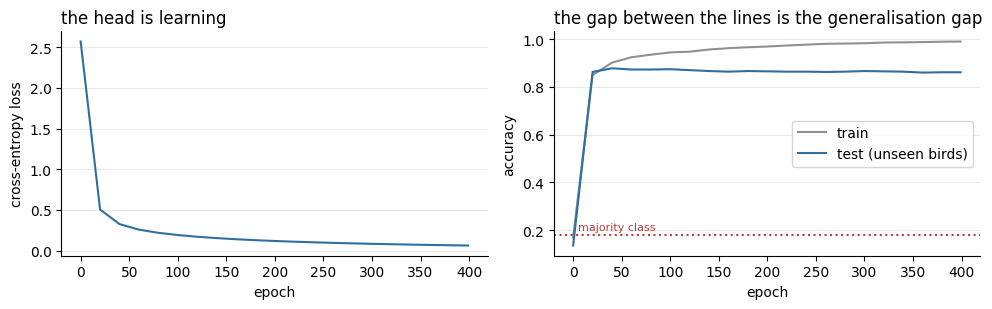

In [4]:
h = np.array(hist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.plot(h[:, 0], h[:, 1], color="#2f6f9f"); ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss"); ax1.set_title("the head is learning", loc="left")
ax2.plot(h[:, 0], h[:, 2], label="train", color="#8b9199")
ax2.plot(h[:, 0], h[:, 3], label="test (unseen birds)", color="#2f6f9f")
ax2.axhline(np.bincount(y).max()/len(y), ls=":", color="#b5423a")
ax2.text(5, np.bincount(y).max()/len(y) + .02, "majority class", color="#b5423a", fontsize=8)
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend()
ax2.set_title("the gap between the lines is the generalisation gap", loc="left")
for a in (ax1, ax2):
    a.spines[["top", "right"]].set_visible(False); a.yaxis.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

### The same thing in one line

`LogisticRegression` is the same model — a linear map to 11 logits, softmax, cross-entropy — fitted
by L-BFGS instead of Adam. It converges to the optimum rather than stopping wherever the epoch
budget ran out, which is why every reported number in this project uses it.

If these two disagree by much, the hand-rolled loop simply has not converged.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

sk = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000)).fit(X[tr], y[tr])
sk_acc = (sk.predict(X[te]) == y[te]).mean()
torch_acc = hist[-1][3]
print(f"PyTorch nn.Linear, 400 Adam steps : {torch_acc:.4f}")
print(f"sklearn LogisticRegression (L-BFGS): {sk_acc:.4f}")
print(f"difference: {abs(sk_acc - torch_acc):.4f}")

PyTorch nn.Linear, 400 Adam steps : 0.8617
sklearn LogisticRegression (L-BFGS): 0.8489
difference: 0.0128


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

## 3. Sweeping the layers, for both encoders

A 12-layer encoder is 12 different feature extractors. Which one is best is an empirical question,
and the answer here is the same for every bioacoustic encoder we have tested: **early layers win**,
and accuracy declines toward the top.

That is the opposite of the intuition imported from NLP, where deeper usually means more semantic.

In [6]:
def probe_all_folds(X, y, groups, n_splits=5, seed=0):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = np.zeros(len(y), dtype=int)
    for tr_, te_ in cv.split(X, y, groups):
        est = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000)).fit(X[tr_], y[tr_])
        pred[te_] = est.predict(X[te_])
    return float((pred == y).mean()), pred

t0 = time.time()
acc_run11, acc_aves = [], []
for L in range(12):
    a, _ = probe_all_folds(E_run11[:, L], y, birds); acc_run11.append(a)
    b, _ = probe_all_folds(E_aves[:, L],  y, birds); acc_aves.append(b)
    print(f"  layer {L:2d}   run11 {a:.4f}   AVES {b:.4f}   diff {a-b:+.4f}")
print(f"\n({time.time()-t0:.0f}s)")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

...

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

  layer 11   run11 0.8048   AVES 0.8127   diff -0.0079

(15s)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

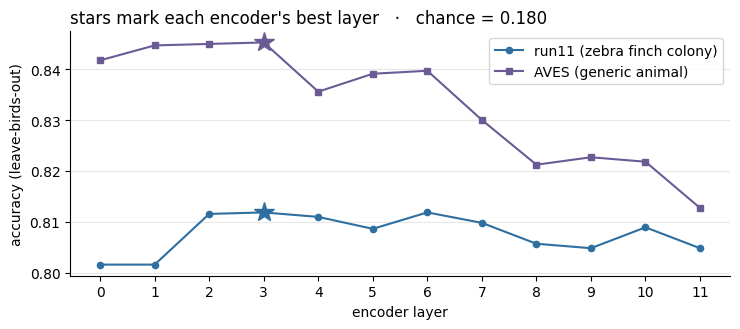

best run11: L3 = 0.8118
best AVES : L3 = 0.8453


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(range(12), acc_run11, "-o", color="#2f6f9f", ms=4.5, label="run11 (zebra finch colony)")
ax.plot(range(12), acc_aves,  "-s", color="#6b5b95", ms=4.5, label="AVES (generic animal)")
for v, c in ((acc_run11, "#2f6f9f"), (acc_aves, "#6b5b95")):
    b = int(np.argmax(v)); ax.plot([b], [v[b]], "*", color=c, ms=15, zorder=5)
ax.set_xticks(range(12)); ax.set_xlabel("encoder layer"); ax.set_ylabel("accuracy (leave-birds-out)")
ax.legend(); ax.spines[["top", "right"]].set_visible(False); ax.yaxis.grid(True, alpha=.3)
ax.set_title(f"stars mark each encoder's best layer   ·   chance = {np.bincount(y).max()/len(y):.3f}",
             loc="left")
plt.tight_layout(); plt.show()
print(f"best run11: L{int(np.argmax(acc_run11))} = {max(acc_run11):.4f}")
print(f"best AVES : L{int(np.argmax(acc_aves))} = {max(acc_aves):.4f}")

## 4. The four ways this silently gives you a wrong number

Each of these produced a real wrong number in this project. None of them raises an error.

### Trap 1 — splitting randomly instead of by bird

Clips from one bird share that bird's voice. Split randomly and the head can recognise the
*individual* and infer the call type from which types that bird tends to produce. It is not cheating
in any detectable way; it just answers an easier question than the one you asked.

In [8]:
from sklearn.model_selection import StratifiedKFold

X3 = E_run11[:, 3]
cvr = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
pred_rand = np.zeros(len(y), dtype=int)
for tr_, te_ in cvr.split(X3, y):
    pred_rand[te_] = make_pipeline(StandardScaler(),
                                   LogisticRegression(max_iter=4000)).fit(X3[tr_], y[tr_]).predict(X3[te_])
rand_acc = (pred_rand == y).mean()
bird_acc, _ = probe_all_folds(X3, y, birds)
print(f"random split      : {rand_acc:.4f}   <- same birds in train and test")
print(f"leave-birds-out   : {bird_acc:.4f}")
print(f"inflation         : {rand_acc - bird_acc:+.4f}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

...

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

random split      : 0.9156   <- same birds in train and test
leave-birds-out   : 0.8118
inflation         : +0.1038


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Trap 2 — choosing the layer on the number you report

Twelve layers is twelve chances. Picking the best one *on the score you then quote* is selection on
the test metric, and the inflation is not small: on bird-identity classification in this project it
was **2.3×** (+0.0286 → +0.0125 once the layer was chosen honestly).

The fix is to choose the layer inside the training fold, with its own inner cross-validation, and
only then touch the test rows.

In [9]:
def probe_layer_chosen_out_of_fold(E, y, groups, n_splits=5, seed=0):
    outer = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = np.zeros(len(y), dtype=int); picked = []
    for tr_, te_ in outer.split(E[:, 0], y, groups):
        best_L, best_a = None, -1.0
        inner = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=seed)
        for L in range(E.shape[1]):
            accs = []
            for itr, ite in inner.split(E[tr_, L], y[tr_], groups[tr_]):
                e = make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=4000)).fit(E[tr_][itr, L], y[tr_][itr])
                accs.append((e.predict(E[tr_][ite, L]) == y[tr_][ite]).mean())
            if np.mean(accs) > best_a:
                best_L, best_a = L, float(np.mean(accs))
        picked.append(best_L)
        e = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=4000)).fit(E[tr_][:, best_L], y[tr_])
        pred[te_] = e.predict(E[te_][:, best_L])
    return float((pred == y).mean()), picked

print("this runs 12 layers x 3 inner folds x 5 outer folds -- about a minute\n")
oof_acc, picked = probe_layer_chosen_out_of_fold(E_run11, y, birds)
print(f"run11, best layer picked on the reported score : {max(acc_run11):.4f}")
print(f"run11, layer chosen out of fold               : {oof_acc:.4f}")
print(f"optimism                                       : {max(acc_run11) - oof_acc:+.4f}")
print(f"layer chosen per fold: {picked}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

this runs 12 layers x 3 inner folds x 5 outer folds -- about a minute



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

...

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

run11, best layer picked on the reported score : 0.8118
run11, layer chosen out of fold               : 0.8025
optimism                                       : +0.0094
layer chosen per fold: [2, 1, 1, 1, 7]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

### Trap 3 — comparing a released feature file against a fresh extraction

Early in this project run11 was scored from its *released* embedding file while AVES was extracted
fresh. Re-extracting both through one identical code path moved run11 by **+0.019** and turned a
"significant" 8-class gap into a non-significant one. The pipeline difference was as large as the
effect being measured.

**Extract both arms yourself, with the same function, or you are measuring your own plumbing.**

### Trap 4 — batching variable-length clips

This one is the nastiest, because it looks like an optimisation.

In [10]:
# Reproduce the padding bug directly.
from aves_holdout import load_run11
enc = load_run11("cpu")

lens  = [int(0.12*16000), int(1.0*16000), int(15.6*16000)]
torch.manual_seed(0)
clips = [torch.randn(1, L) * 0.05 for L in lens]

single = [enc.feature_extractor(c, None)[0].squeeze(0) for c in clips]   # one at a time
batch  = torch.zeros(len(clips), max(lens))                              # zero-padded batch
for i, c in enumerate(clips):
    batch[i, :c.shape[1]] = c[0]

for tag, L in (("lengths=None", None), ("lengths=passed", torch.tensor(lens))):
    out = enc.feature_extractor(batch, L)[0]
    print(f"\n{tag}")
    for i in range(len(clips)):
        nv = single[i].shape[0]
        print(f"   clip {lens[i]/16000:5.2f}s   max|batched - single| at VALID frames = "
              f"{(out[i,:nv] - single[i]).abs().max().item():9.4f}")


lengths=None
   clip  0.12s   max|batched - single| at VALID frames =  121.4087
   clip  1.00s   max|batched - single| at VALID frames =   60.7590
   clip 15.60s   max|batched - single| at VALID frames =    0.0000



lengths=passed
   clip  0.12s   max|batched - single| at VALID frames =  121.4087
   clip  1.00s   max|batched - single| at VALID frames =   60.7590
   clip 15.60s   max|batched - single| at VALID frames =    0.0000


The short clips are corrupted by two orders of magnitude, **at their valid frames**, and passing
`lengths` changes nothing. The longest clip — the one that defines the batch length and therefore
carries no padding — is exact.

**Why:** `extractor_mode="group_norm"` places a `GroupNorm(512, 512)` inside convolutional block 0
that normalises over **time**. Zero padding changes each clip's time statistics, so the normalisation
output shifts everywhere. `lengths` only masks transformer attention, which is downstream.

This is the same failure that produced a widely-believed ~60% figure for AVES on this task in 2023:
there, clips were padded to 15.66 s and mean-pooled over ~782 frames of which 99.1% were padding.
Correctly encoded, the same checkpoint scores 0.845.

**Rule: encode one clip at a time, or recompute that normalisation over real frames — and assert
batched == single to ~1e-5 before you trust any batched extraction.**

## 5. What the honest number is

Putting the traps together for the headline comparison.

In [11]:
import pandas as pd
oof_aves, picked_a = probe_layer_chosen_out_of_fold(E_aves, y, birds)
tbl = pd.DataFrame([
    ["best layer picked on the reported score", max(acc_run11), max(acc_aves)],
    ["layer chosen out of fold",                oof_acc,        oof_aves],
    ["random split (INFLATED - do not use)",    rand_acc,       np.nan],
], columns=["protocol", "run11", "AVES"])
tbl["AVES - run11"] = tbl["AVES"] - tbl["run11"]
display(tbl.style.format({"run11": "{:.4f}", "AVES": "{:.4f}", "AVES - run11": "{:+.4f}"}))
print(f"\nchance (majority class) = {np.bincount(y).max()/len(y):.4f}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

...

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

,protocol,run11,AVES,AVES - run11
0,best layer picked on the reported score,0.8118,0.8453,+0.0334
1,layer chosen out of fold,0.8025,0.8394,+0.0369
2,random split (INFLATED - do not use),0.9156,nan,+nan



chance (majority class) = 0.1797


## What to take away

1. **The head is 8,459 parameters against a frozen 94.4 M encoder.** Whatever it achieves is a
   statement about the features, not about the head. That is the whole design.
2. **Early layers win**, for every bioacoustic encoder tested here — the opposite of the NLP
   intuition.
3. **Chance is the majority class**, not 1/11. Quote it next to every accuracy.
4. **Four silent failure modes**: random splits, layer selection on the reported metric, mixing
   released features with fresh ones, and batching variable-length audio. None raises an error, and
   each one produced a wrong number here before it was caught.

Next: `ZF_AVES_full_comparison.ipynb` for the complete model comparison across detection,
classification, and identity.